In [95]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm
import numpy as np
from datetime import date

In [96]:
VARIABLE = "heat_index" # "edv", "temp", or "heat_index"

assert VARIABLE in ["edv", "temp", "heat_index"], f"invalid `VARIABLE` value: {VARIABLE}"

INPUT_FILE = f"../data/{VARIABLE}/regional_{VARIABLE}_data.csv"
OUTPUT_FILE = f"../data/{VARIABLE}/{VARIABLE}_seasonality.csv"
PLOT_OUTPUT_FILE = f"../plots/seasonality/{VARIABLE}_seasonality.png"
USE_LN = VARIABLE == "edv" # only EDV is transformed since it is a count variable

if VARIABLE == "edv":
    suptitle = "EDV"
elif VARIABLE == "temp":
    suptitle = "Temperature"
elif VARIABLE == "heat_index":
    suptitle = "Heat Index"

In [97]:
OMEGA = 1/365.25
PHI = 2*np.pi*OMEGA

def f(t, beta_0, beta_s, beta_c):
    if USE_LN:
        return np.exp(beta_0 + beta_s*np.sin(PHI*t) + beta_c*np.cos(PHI*t))
    else:
        return beta_0 + beta_s*np.sin(PHI*t) + beta_c*np.cos(PHI*t)

In [98]:
df = pd.read_csv(INPUT_FILE, index_col=0)
y_min = df.values.min()
y_max = df.values.max()
y_range = y_max - y_min
df.index = pd.to_datetime(df.index)
df = df[df.index.year >= 2018]
df.head()

,Region 1,Region 2,Region 3,Region 4,Region 5,Region 6,Region 7,Region 8,Region 9,Region 10
2018-01-01,-12.678857,-9.902477,-7.289966,2.292726,-12.558602,-1.847003,-13.580701,-2.862781,15.558656,2.593883
2018-01-02,-7.542560,-5.858637,-5.863961,1.575768,-10.988037,-1.269446,-8.547216,-0.550345,16.521210,3.334063
2018-01-03,-3.327857,-4.757966,-2.155499,3.519886,-9.141144,5.502734,-6.078281,0.754320,15.804429,4.351690
2018-01-04,0.075534,-3.740864,-3.960531,1.426547,-10.454492,7.256521,-5.855816,1.686066,14.377746,4.011584
2018-01-05,-6.550678,-10.283494,-9.127106,2.467051,-11.557836,10.320760,-4.170704,2.500222,15.062658,5.430839


In [99]:
START_DATE = df.index.min().to_pydatetime().date()
END_DATE = df.index.max().to_pydatetime().date()
x_tick_ts = []
x_tick_years = []
for year in range(START_DATE.year, END_DATE.year+2, 2):
    days_since = (date(year, 1, 1) - START_DATE).days + 1
    x_tick_ts.append(days_since)
    x_tick_years.append(year)

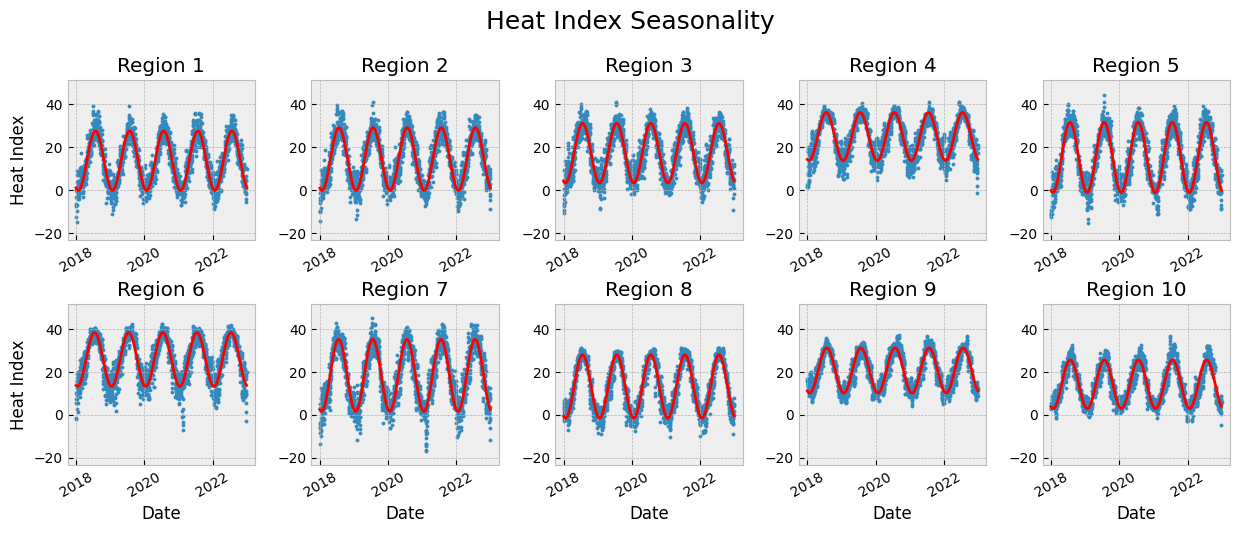

,region,beta_0,beta_s,beta_c,sigma_00,sigma_0s,sigma_0c,sigma_ss,sigma_sc,sigma_cc,psi,var_psi,peak_T,sigma_peak_T,peak_T_CI_lower,peak_T_CI_upper,gamma,var_gamma,theta
0,Region 1,13.764436,-5.713487,-12.611466,0.009851,-2.899818e-08,0.000003,0.019699,-5.800600e-08,0.019705,0.425378,0.000103,207.352816,0.589311,206.197788,208.507843,13.845324,0.019704,1.030262e+06
1,Region 2,14.529561,-5.468688,-13.557571,0.010660,-3.137522e-08,0.000003,0.021318,-6.278683e-08,0.021323,0.383406,0.000100,204.912923,0.580593,203.774981,206.050865,14.618970,0.021323,2.233254e+06
2,Region 3,17.277214,-4.781347,-13.042305,0.011559,-3.402756e-08,0.000003,0.023114,-6.807601e-08,0.023120,0.351389,0.000120,203.051690,0.636234,201.804693,204.298686,13.891113,0.023119,1.078533e+06
3,Region 4,25.005752,-3.512666,-10.657310,0.008422,-2.479753e-08,0.000002,0.016842,-4.959161e-08,0.016847,0.318388,0.000134,201.133331,0.672317,199.815613,202.451049,11.221278,0.016846,7.470320e+04
4,Region 5,15.312760,-5.500235,-15.416348,0.011466,-3.375445e-08,0.000003,0.022929,-6.751995e-08,0.022935,0.342702,0.000086,202.546701,0.537790,201.492653,203.600749,16.368151,0.022935,1.284096e+07
5,Region 6,25.789903,-3.242669,-12.138595,0.010693,-3.149064e-08,0.000003,0.021382,-6.295058e-08,0.021388,0.261042,0.000135,197.799696,0.676560,196.473663,199.125729,12.564251,0.021388,2.861442e+05
6,Region 7,18.375789,-5.243565,-15.954593,0.014420,-4.241896e-08,0.000004,0.028837,-8.496095e-08,0.028844,0.317535,0.000102,201.083716,0.587801,199.931648,202.235784,16.794166,0.028844,1.966136e+07
7,Region 8,13.214735,-5.142579,-13.839057,0.007189,-2.116912e-08,0.000002,0.014377,-4.234271e-08,0.014381,0.355786,0.000066,203.307293,0.472121,202.381953,204.232633,14.763659,0.014380,2.580926e+06
8,Region 9,20.661954,-4.403718,-9.554748,0.005476,-1.612607e-08,0.000001,0.010951,-3.225091e-08,0.010954,0.431876,0.000099,207.730516,0.578229,206.597207,208.863824,10.520738,0.010953,3.707649e+04
9,Region 10,14.213572,-4.270944,-10.500783,0.006394,-1.882513e-08,0.000002,0.012785,-3.767342e-08,0.012789,0.386291,0.000099,205.080640,0.579844,203.944167,206.217113,11.336110,0.012788,8.379348e+04


In [100]:
plt.style.use('bmh')

fig, axs = plt.subplots(2, 5, figsize=(15, 5))
plt.subplots_adjust(wspace=0.3, hspace=0.4)
data = []
for i, region in enumerate(df.columns):
    x = np.arange(len(df.index))
    y = df[region]
    betas, covs = curve_fit(f, x, y)

    beta_0, beta_s, beta_c = betas
    (sigma_00, sigma_0s, sigma_0c),\
    (_,        sigma_ss, sigma_sc),\
    (_,        _,        sigma_cc) = covs

    psi = np.arctan(beta_s/beta_c)
    var_psi = ((beta_c**2 * sigma_ss) + (beta_s**2 * sigma_cc) - (2 * sigma_sc * beta_s * beta_c)) / (beta_c**2 + beta_s**2)**2
    if beta_s > 0 and beta_c > 0:
        peak_T = psi / PHI
    elif beta_c < 0:
        peak_T = (psi + np.pi) / PHI
    else:
        peak_T = (psi + 2*np.pi) / PHI
    sigma_peak_T = np.sqrt(var_psi) / PHI
    z = norm.ppf(0.975)
    peak_T_CI = (peak_T - z*sigma_peak_T, peak_T + z*sigma_peak_T)
    gamma = np.sqrt(beta_c**2 + beta_s**2)
    var_gamma = ((beta_c**2 * sigma_cc) + (beta_s**2 * sigma_ss) - (2 * sigma_sc * beta_s * beta_c)) / (beta_c**2 + beta_s**2)
    theta = np.exp(gamma)
    M = z # M not specified in paper
    theta_CI = (np.exp(gamma - M*np.sqrt(var_gamma)), np.exp(gamma + M*np.sqrt(var_gamma)))

    data.append({
        "region": region,
        "beta_0": beta_0, "beta_s": beta_s, "beta_c": beta_c,
        "sigma_00": sigma_00, "sigma_0s": sigma_0s, "sigma_0c": sigma_0c, "sigma_ss": sigma_ss, "sigma_sc": sigma_sc, "sigma_cc": sigma_cc,
        "psi": psi, "var_psi": var_psi,
        "peak_T": peak_T, "sigma_peak_T": sigma_peak_T, "peak_T_CI_lower": peak_T_CI[0], "peak_T_CI_upper": peak_T_CI[1],
        "gamma": gamma, "var_gamma": var_gamma, "theta": theta,
        # "theta_CI_lower": theta_CI[0], "theta_CI_upper": theta_CI[1]
    })

    row = i//5
    col = i%5
    ax = axs[row,col]
    ax.scatter(x, y, s = 5)
    ax.plot(x, f(x, *betas), color = "red")
    ax.set_title(region)
    if VARIABLE == "edv":
        ax.set_ylim(0, 2000)
    else:
        ax.set_ylim(y_min - y_range*0.1, y_max + y_range*0.1)
    ax.set_xticks(x_tick_ts, x_tick_years, rotation = 30)
    if row == 1:
        ax.set_xlabel("Date")
    if col == 0:
        ax.set_ylabel(suptitle)
    
        
plt.suptitle(f"{suptitle} Seasonality", fontsize = 18, y = 1.02)

plt.savefig(PLOT_OUTPUT_FILE, dpi = 500, bbox_inches = "tight")
plt.show()
df_models = pd.DataFrame(data)
df_models

In [ ]:
df_models.to_csv(OUTPUT_FILE, index = False)

: 